<h1><strong>Sampling</strong></h1>

    Sampling is the process of selecting a statistical subset (a sample) form a large group (the population) to estimate characterstics of the entire group. Because analyzing and entire group is often computationally impossible or economically unfeasible, we rely on samples.

<h1><strong>Resampling</strong></h1>

    Resampling is the process of repeatedly drawing samples from you existing, original sample to assess the variability of statistics or model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

population_size=1000
ages = np.random.normal(loc=45,scale=15,size=population_size)
ages = np.clip(ages,18,90)

incomes = 30000 + (ages * 1000) + np.random.normal(0,15000,population_size)

population_df = pd.DataFrame({"Age":ages,'Income':incomes})

sample = population_df.sample(n=200,random_state=42)




In [3]:
sample.shape

(200, 2)

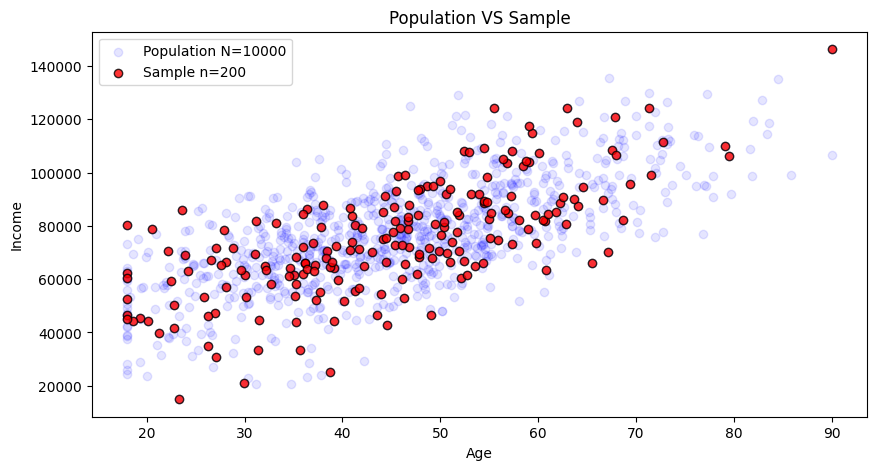

In [5]:
plt.figure(figsize=(10,5))

plt.scatter(population_df['Age'],population_df['Income'],alpha=0.1,label='Population N=10000',color='blue')
plt.scatter(sample['Age'],sample['Income'],alpha=0.8,label='Sample n=200',color='red',edgecolor='black')
plt.title("Population VS Sample")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.show()

<h2><strong>Types of sampling</strong></h2>

- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling

<h3>Systematic Sampling</h3>

In [7]:
production_line = np.arange(0,100)

k = 10

start_index = 1

systematic_sample = production_line[start_index::k]
systematic_sample

array([ 1, 11, 21, 31, 41, 51, 61, 71, 81, 91])

<h3>Stratified Sampling</h3>

Dividing the into homogeneous subgroups (strata) and taking a random sample from each stratum proportional to its size.

In [8]:
health_status = ['Healthy']*900 + ['Sick']*100

df_health = pd.DataFrame({'ID':np.arange(1000),'Status':health_status})

In [10]:
df_health['Status'].value_counts()

Status
Healthy    900
Sick       100
Name: count, dtype: int64

In [18]:
sample_size = 100

frac_value = sample_size/ len(df_health)

strat_sample = df_health.groupby(
    'Status',
    group_keys=False
    ).sample(
        frac=frac_value,
        random_state=42
    )

In [23]:
strat_sample

,ID,Status
70,70,Healthy
827,827,Healthy
231,231,Healthy
588,588,Healthy
39,39,Healthy
...,...,...
949,949,Sick
924,924,Sick
978,978,Sick
915,915,Sick


In [22]:
pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    strat_sample[['ID']],
    strat_sample['Status'],
    test_size=0.20,
    random_state=42,
    stratify=strat_sample['Status'])

In [29]:
X_test

,ID
536,536
583,583
66,66
352,352
827,827
741,741
522,522
957,957
493,493
448,448


<h1>Resampling</h1>
<h3>K-Fold Method </h3>

In [31]:
from sklearn.model_selection import KFold

X_cv = np.array([[1],[2],[3],[4],[5]])
y_cv = np.array([0,1,0,1,0])

kf = KFold(n_splits=5,shuffle=True,random_state=42)

fold = 1

for train_index,test_index in kf.split(X_cv):
    print(f"Fold {fold} | Train indices: {train_index} | Test Indices: {test_index}")
    fold+=1

Fold 1 | Train indices: [0 2 3 4] | Test Indices: [1]
Fold 2 | Train indices: [0 1 2 3] | Test Indices: [4]
Fold 3 | Train indices: [0 1 3 4] | Test Indices: [2]
Fold 4 | Train indices: [1 2 3 4] | Test Indices: [0]
Fold 5 | Train indices: [0 1 2 4] | Test Indices: [3]
